## Importing the Libraries


In [1]:
import pandas as pd
import numpy as np

## Importing the Dataset And Getting Info 


In [2]:
dataset = pd.read_csv('../data/audi.csv')
print(dataset.head())
print(dataset.info())

  model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0    A1  2017  12500       Manual    15735   Petrol  150  55.4         1.4
1    A6  2016  16500    Automatic    36203   Diesel   20  64.2         2.0
2    A1  2016  11000       Manual    29946   Petrol   30  55.4         1.4
3    A4  2017  16800    Automatic    25952   Diesel  145  67.3         2.0
4    A3  2019  17300       Manual     1998   Petrol  145  49.6         1.0
<class 'pandas.DataFrame'>
RangeIndex: 10668 entries, 0 to 10667
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10668 non-null  str    
 1   year          10668 non-null  int64  
 2   price         10668 non-null  int64  
 3   transmission  10668 non-null  str    
 4   mileage       10668 non-null  int64  
 5   fuelType      10668 non-null  str    
 6   tax           10668 non-null  int64  
 7   mpg           10668 non-null  float64
 8   engineSize    1066

## EDA

In [3]:
# Look for missing Values
print(dataset.isnull().sum())

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


In [4]:
## Summary Statistics 
print(dataset.describe())

               year          price        mileage           tax           mpg  \
count  10668.000000   10668.000000   10668.000000  10668.000000  10668.000000   
mean    2017.100675   22896.685039   24827.244001    126.011436     50.770022   
std        2.167494   11714.841888   23505.257205     67.170294     12.949782   
min     1997.000000    1490.000000       1.000000      0.000000     18.900000   
25%     2016.000000   15130.750000    5968.750000    125.000000     40.900000   
50%     2017.000000   20200.000000   19000.000000    145.000000     49.600000   
75%     2019.000000   27990.000000   36464.500000    145.000000     58.900000   
max     2020.000000  145000.000000  323000.000000    580.000000    188.300000   

         engineSize  
count  10668.000000  
mean       1.930709  
std        0.602957  
min        0.000000  
25%        1.500000  
50%        2.000000  
75%        2.000000  
max        6.300000  


In [5]:
# Print Unique Values for Categorical Columns
print("Unique Models: ", dataset['model'].unique())
print("Unique Fuel Type: ", dataset['fuelType'].unique())
print("Unique Transmissions: ", dataset['transmission'].unique())


Unique Models:  <ArrowStringArray>
[ ' A1',  ' A6',  ' A4',  ' A3',  ' Q3',  ' Q5',  ' A5',  ' S4',  ' Q2',
  ' A7',  ' TT',  ' Q7', ' RS6', ' RS3',  ' A8',  ' Q8', ' RS4', ' RS5',
  ' R8', ' SQ5',  ' S8', ' SQ7',  ' S3',  ' S5',  ' A2', ' RS7']
Length: 26, dtype: str
Unique Fuel Type:  <ArrowStringArray>
['Petrol', 'Diesel', 'Hybrid']
Length: 3, dtype: str
Unique Transmissions:  <ArrowStringArray>
['Manual', 'Automatic', 'Semi-Auto']
Length: 3, dtype: str


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
numerical_cols = ['year', 'price', 'mileage','tax', 'mpg','engineSize']

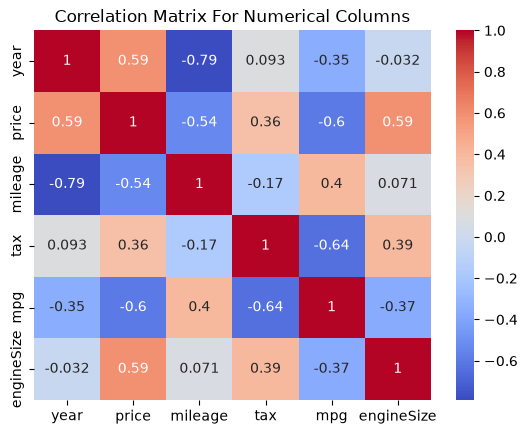

In [8]:
## Correlation Matrix for Numerical Columns
corr_matrix = dataset[numerical_cols].corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.title('Correlation Matrix For Numerical Columns')
plt.show()

## Data Preprocessing

In [9]:
X = dataset.drop('price',axis = 1)
y = dataset['price']
print(X)

      model  year transmission  mileage fuelType  tax   mpg  engineSize
0        A1  2017       Manual    15735   Petrol  150  55.4         1.4
1        A6  2016    Automatic    36203   Diesel   20  64.2         2.0
2        A1  2016       Manual    29946   Petrol   30  55.4         1.4
3        A4  2017    Automatic    25952   Diesel  145  67.3         2.0
4        A3  2019       Manual     1998   Petrol  145  49.6         1.0
...     ...   ...          ...      ...      ...  ...   ...         ...
10663    A3  2020       Manual     4018   Petrol  145  49.6         1.0
10664    A3  2020       Manual     1978   Petrol  150  49.6         1.0
10665    A3  2020       Manual      609   Petrol  150  49.6         1.0
10666    Q3  2017    Automatic     8646   Petrol  150  47.9         1.4
10667    Q3  2016       Manual    11855   Petrol  150  47.9         1.4

[10668 rows x 8 columns]


In [10]:
# Encoding Categorical Data 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
categorical_cols = ['transmission','fuelType', 'model']
ct = ColumnTransformer(transformers=[
    ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),categorical_cols)
],remainder='passthrough')
X = ct.fit_transform(X)

In [11]:
# show new feature names
print(X.shape)
ct.get_feature_names_out()

(10668, 34)


array(['encoder__transmission_Manual', 'encoder__transmission_Semi-Auto',
       'encoder__fuelType_Hybrid', 'encoder__fuelType_Petrol',
       'encoder__model_ A2', 'encoder__model_ A3', 'encoder__model_ A4',
       'encoder__model_ A5', 'encoder__model_ A6', 'encoder__model_ A7',
       'encoder__model_ A8', 'encoder__model_ Q2', 'encoder__model_ Q3',
       'encoder__model_ Q5', 'encoder__model_ Q7', 'encoder__model_ Q8',
       'encoder__model_ R8', 'encoder__model_ RS3', 'encoder__model_ RS4',
       'encoder__model_ RS5', 'encoder__model_ RS6',
       'encoder__model_ RS7', 'encoder__model_ S3', 'encoder__model_ S4',
       'encoder__model_ S5', 'encoder__model_ S8', 'encoder__model_ SQ5',
       'encoder__model_ SQ7', 'encoder__model_ TT', 'remainder__year',
       'remainder__mileage', 'remainder__tax', 'remainder__mpg',
       'remainder__engineSize'], dtype=object)

## Splitting the Data Into The Training and Test Set

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

## Feature Scaling

In [13]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
sc_y = StandardScaler()
X_train = sc_X.fit_transform(X_train)
y_train = y_train.values.reshape(-1,1) # standard scaler expects a 2D array 
y_train = sc_y.fit_transform(y_train).ravel() # ravel() takes it back to a 1D array since our model expects 1D

In [14]:
y_train.shape

(8534,)

## Training The Support Vector Regression Model on The Training Set

In [15]:
from sklearn.svm import SVR
regressor = SVR(kernel='rbf')
regressor.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


## Saving The Model

In [16]:
import joblib
joblib.dump(regressor,'svr_model_audi_cars.pkl')
joblib.dump(ct,'ct_svr.pkl')
joblib.dump(sc_X,'sc_X_svr.pkl')
joblib.dump(sc_y,'sc_y_svr.pkl')

['sc_y_svr.pkl']

## Predicting the Test Set Results

In [17]:
y_pred = sc_y.inverse_transform(regressor.predict(sc_X.transform(X_test)).reshape(-1,1))
np.set_printoptions(precision=2) #only show 2 decimals for floating point nummbers
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.values.reshape(len(y_test),1)),axis = 1)) # join the two arrays into a column


[[13493.53 14998.  ]
 [24769.83 21950.  ]
 [29101.82 28990.  ]
 ...
 [47694.1  45995.  ]
 [30983.62 30500.  ]
 [ 9453.56  8400.  ]]


# Predicting the price of a Specific Audi Car

In [18]:
new_audi1 = pd.DataFrame({
    'model': ['A1'],
    'year': [2017],
    'transmission': ['Manual'],
    'mileage': [15735],
    'fuelType': ['Petrol'],
    'tax': [150],
    'mpg': [55.4],
    'engineSize': [1.4]
})
# Encoding the new car
new_audi1_encoded = ct.transform(new_audi1)
# Feature scaling the new car
new_audi1_scaled = sc_X.transform(new_audi1_encoded)
# Predicting the new car price (scaled)
pred_scaled = regressor.predict(new_audi1_scaled)
# Getting actual price 
pred_price = sc_y.inverse_transform(pred_scaled.reshape(-1,1))
print(f"The predicted price is ${pred_price[0][0]:.2f}")


The predicted price is $14191.13


c:\Users\Daniel\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Evaluating the Model's Performance

In [19]:
from sklearn.metrics import r2_score
r2_test = r2_score(y_test,y_pred)
print(f"Test R² is: {r2_test:.4f}")

Test R² is: 0.9503


## Checking for Overfitting

In [20]:
# We'll check the R² Score of the training data now
# Predicting on the training set(scaled)
y_train_pred_scaled = regressor.predict(X_train)
# Converting to Real Price
y_train_pred = sc_y.inverse_transform(y_train_pred_scaled.reshape(-1,1))
# Getting Actual (unscaled) training prices for comparison
y_train_actual = sc_y.inverse_transform(y_train.reshape(-1,1))

# R² on Training Data
r2_train = r2_score(y_train_actual,y_train_pred)
print(f"Training R² is: {r2_train:.4f}")

Training R² is: 0.9456


##  Visualizing the Predicted vs Actual Points

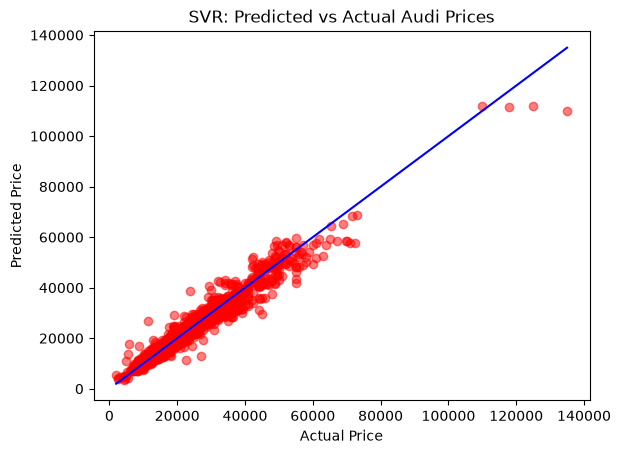

In [21]:
plt.scatter(y_test, y_pred, color='red',alpha=0.5) #alpha handles transparency
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='blue')  # perfect prediction line takes all x valuues first the y values (min,min) and (max,max)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('SVR: Predicted vs Actual Audi Prices')
plt.show()